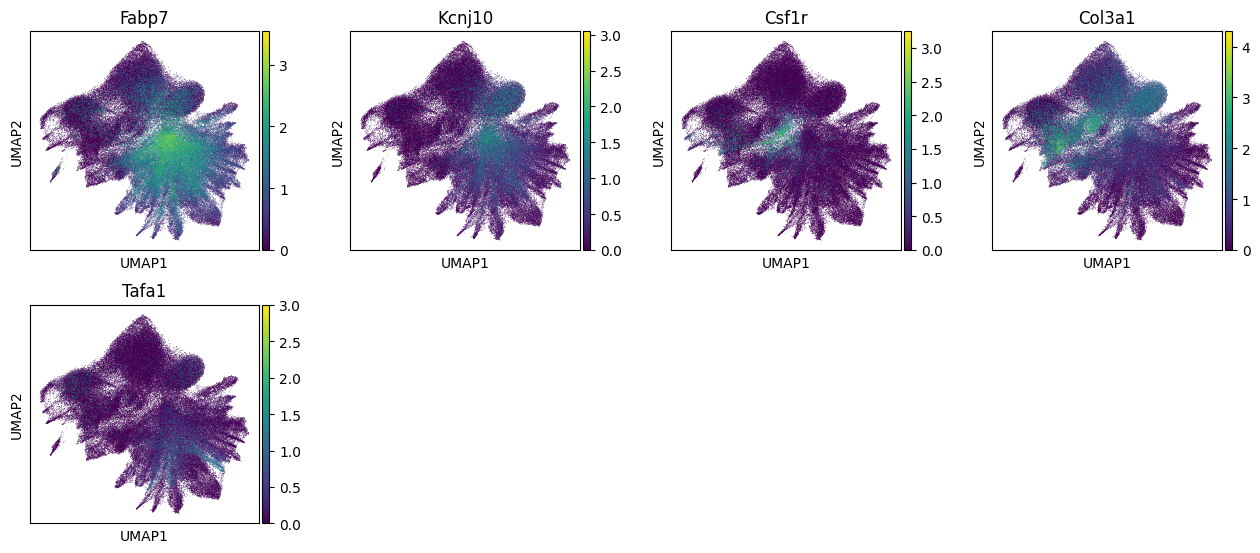

In [53]:
sc.pl.umap(adata, color = ['Fabp7', 'Kcnj10', 'Csf1r', 'Col3a1', 'Tafa1'])

In [24]:
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (3,3)
plt.rcParams['figure.dpi'] = 100


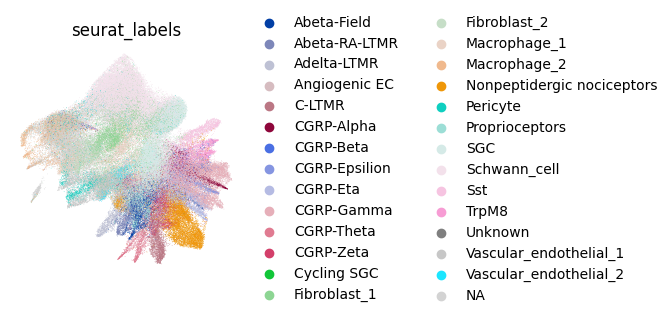

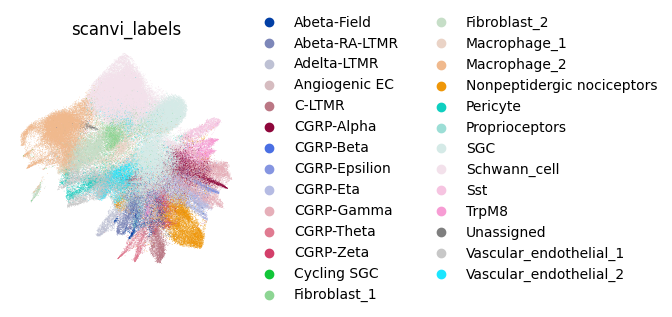

In [25]:
sc.pl.umap(adata, color = ['seurat_labels'], frameon = False)
sc.pl.umap(adata, color = ['scanvi_labels'], frameon = False)

In [32]:
import matplotlib.pyplot as plt
import scanpy as sc
import numpy as np

def plot_side_by_side_annotations(
    adata,
    seurat_key="seurat_labels",
    scanvi_key="scanvi_labels",
    point_size=2,
):

    # --- Extract Seurat label list safely ---
    seurat_labels = adata.obs[seurat_key].dropna().astype(str).unique()
    seurat_labels = sorted(seurat_labels)

    nrows = len(seurat_labels)
    ncols = 2

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(10, 3 * nrows),
        squeeze=False
    )

    for i, label in enumerate(seurat_labels):

        # LEFT COLUMN — Seurat
        sc.pl.umap(
            adata,
            color=seurat_key,
            groups=[label],
            palette=["red"],
            show=False,
            ax=axes[i, 0],
            size=point_size,
            frameon=False,
            title=f"Seurat: {label}",
        )

        # RIGHT COLUMN — scANVI
        sc.pl.umap(
            adata,
            color=scanvi_key,
            groups=[label],
            palette=["blue"],
            show=False,
            ax=axes[i, 1],
            size=point_size,
            frameon=False,
            title=f"scANVI: {label}",
        )

    plt.tight_layout()
    plt.show()

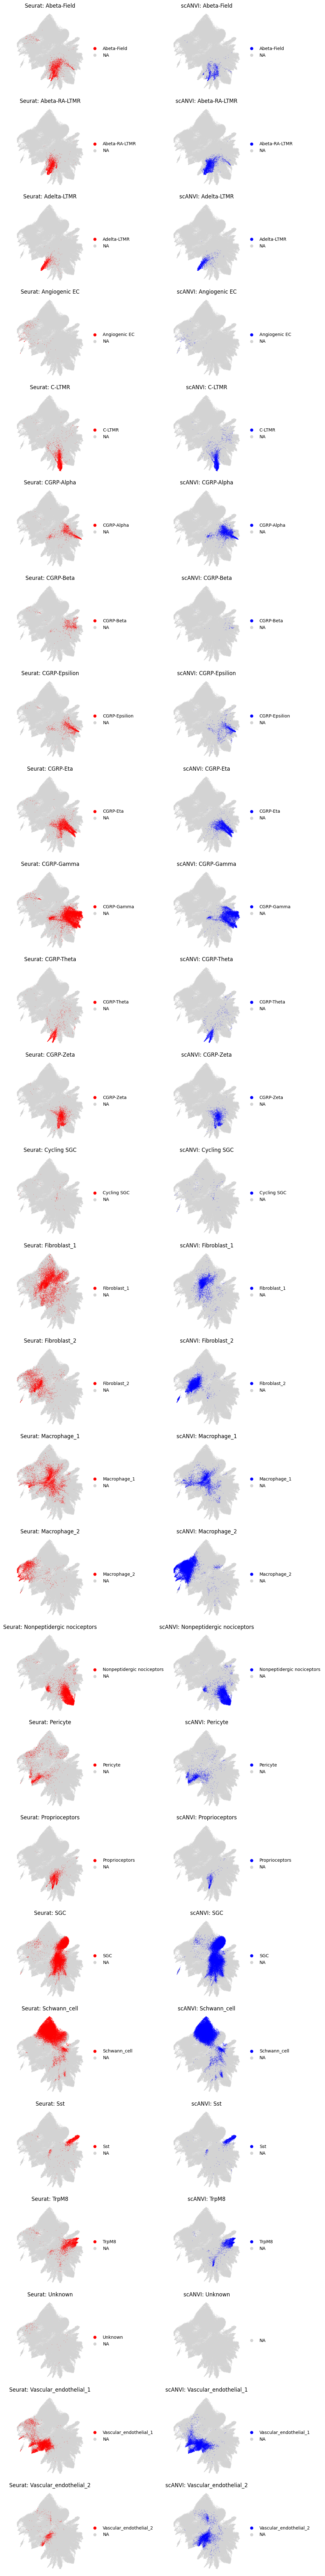

In [33]:
plot_side_by_side_annotations(adata)

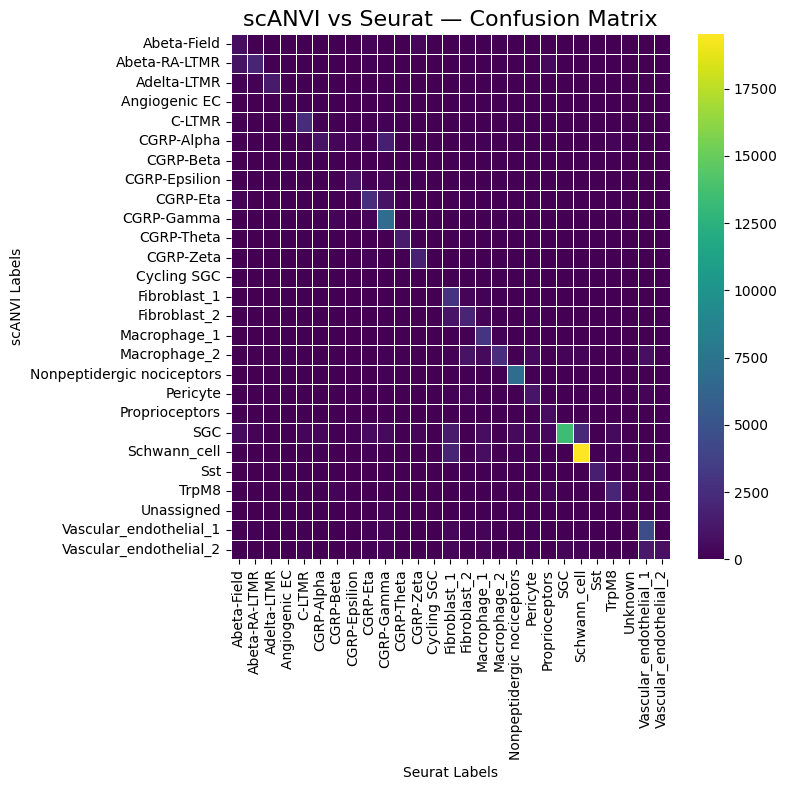

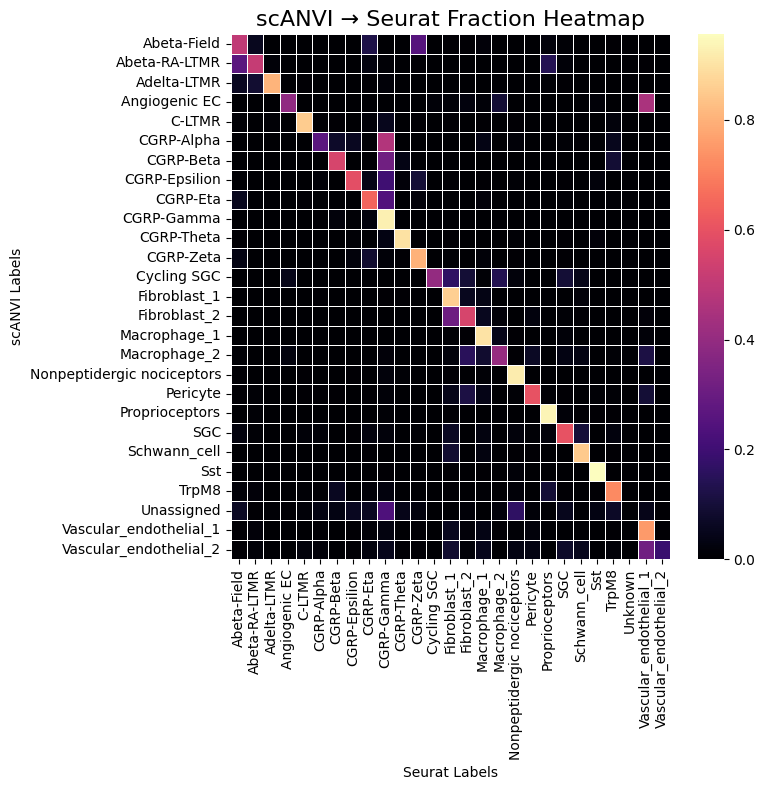

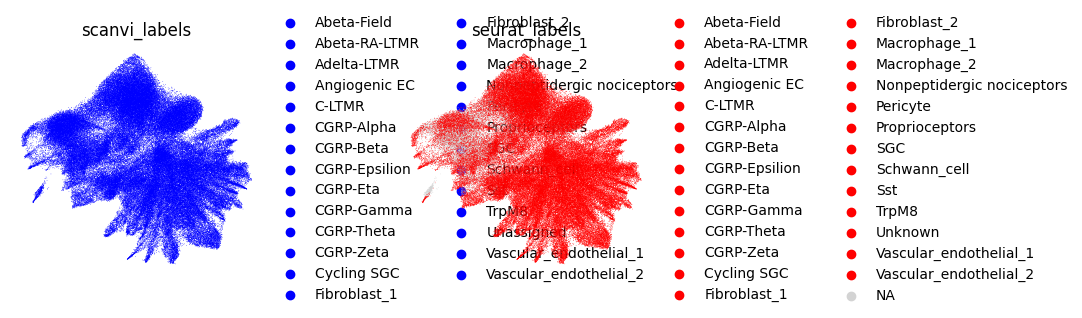

In [46]:
import scanpy as sc
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------
# 1. Build confusion matrix
# -------------------------
confusion = pd.crosstab(
    adata.obs["scanvi_labels"],
    adata.obs["seurat_labels"],
    rownames=["scANVI"],
    colnames=["Seurat"],
    dropna=False
)

# -------------------------
# 2. Plot raw confusion heatmap
# -------------------------
plt.figure(figsize=(8,8))
sns.heatmap(confusion, cmap="viridis", linewidths=0.4)
plt.title("scANVI vs Seurat — Confusion Matrix", fontsize=16)
plt.xlabel("Seurat Labels")
plt.ylabel("scANVI Labels")
plt.tight_layout()
plt.show()

# -------------------------
# 3. Plot normalized heatmap (fraction per scANVI label)
# -------------------------
plt.figure(figsize=(8,8))
sns.heatmap(
    confusion.div(confusion.sum(axis=1), axis=0),
    cmap="magma",
    linewidths=0.4
)
plt.title("scANVI → Seurat Fraction Heatmap", fontsize=16)
plt.xlabel("Seurat Labels")
plt.ylabel("scANVI Labels")
plt.tight_layout()
plt.show()

In [48]:
import numpy as np
import pandas as pd
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# Convert categoricals → strings for safe comparison
scanvi = adata.obs["scanvi_labels"].astype(str)
seurat = adata.obs["seurat_labels"].astype(str)

# Confusion matrix
confusion = pd.crosstab(scanvi, seurat)

# 1) Overall accuracy
overall_accuracy = np.mean(scanvi == seurat)

# 2) Adjusted Rand Index (ARI)
ari = adjusted_rand_score(scanvi, seurat)

# 3) Normalized Mutual Information (NMI)
nmi = normalized_mutual_info_score(scanvi, seurat)

print("-------------------------------------------------------")
print("SCANVI vs SEURAT AGREEMENT METRICS")
print("-------------------------------------------------------")
print(f"Overall Accuracy:           {overall_accuracy:.4f}")
print(f"Adjusted Rand Index (ARI):  {ari:.4f}")
print(f"Normalized Mutual Info:     {nmi:.4f}")
print("-------------------------------------------------------")

-------------------------------------------------------
SCANVI vs SEURAT AGREEMENT METRICS
-------------------------------------------------------
Overall Accuracy:           0.5576
Adjusted Rand Index (ARI):  0.3975
Normalized Mutual Info:     0.5426
-------------------------------------------------------


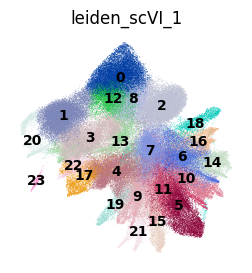

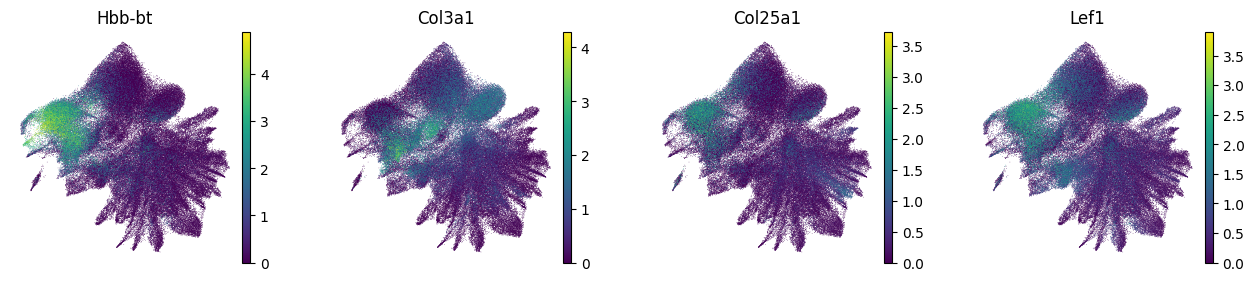

In [64]:
sc.pl.umap(adata, color = 'leiden_scVI_1', legend_loc = 'on data', frameon = False)
sc.pl.umap(adata, color = ['Hbb-bt', 'Col3a1', 'Col25a1', 'Lef1'], legend_loc = 'on data', frameon = False)

/home/workspace/environment/sc-charter/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:429: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/home/workspace/environment/sc-charter/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:431: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/home/workspace/environment/sc-charter/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:

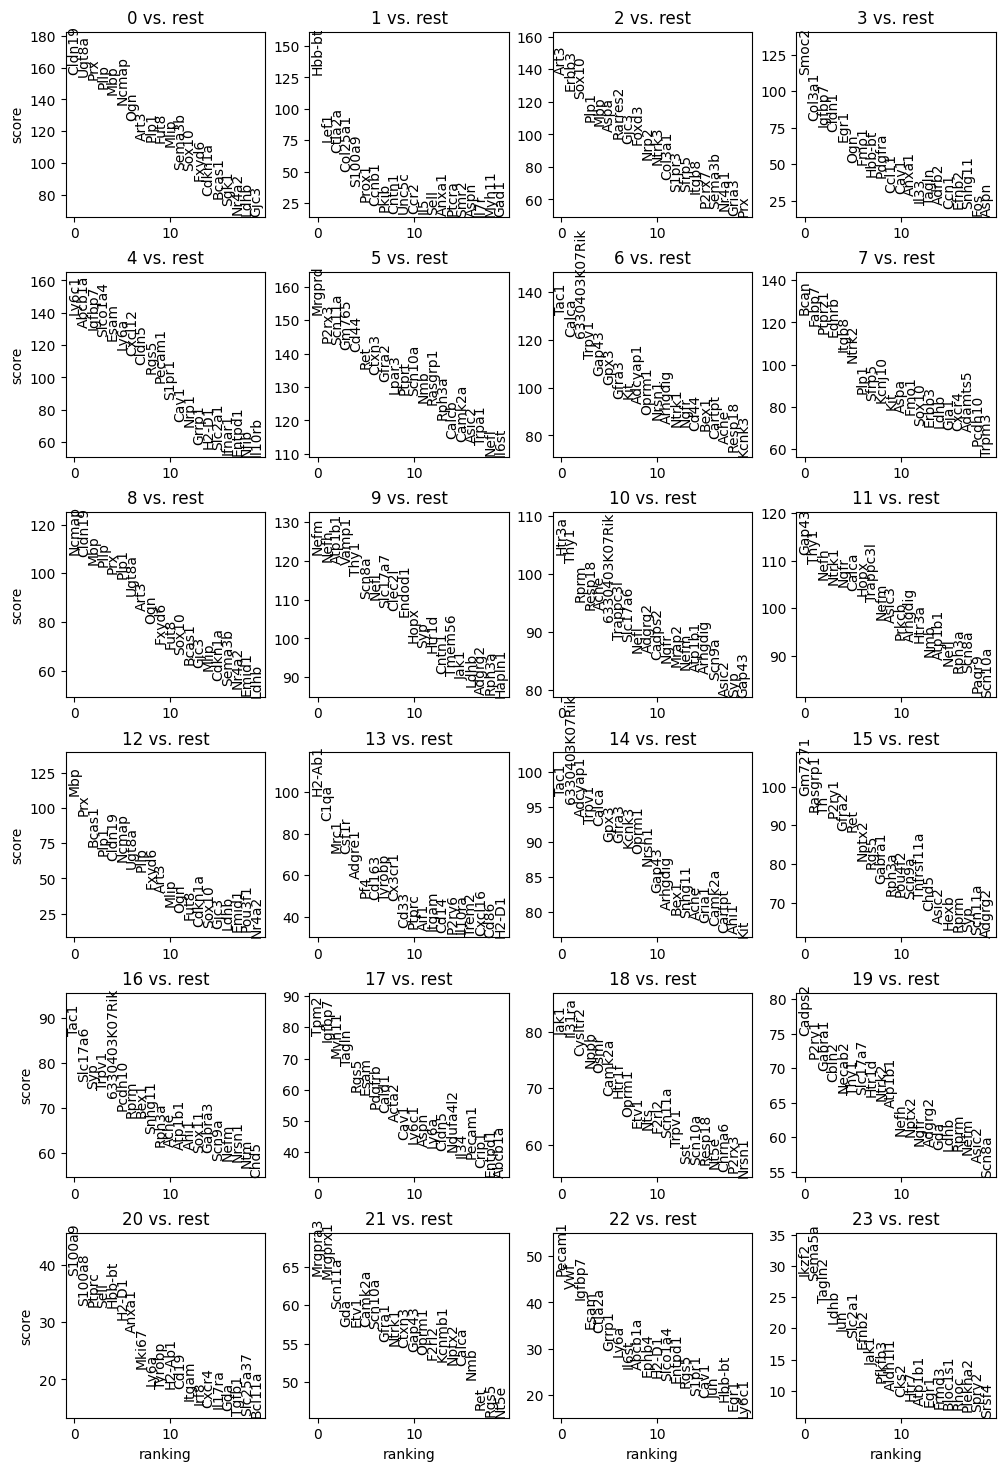

In [55]:
sc.tl.rank_genes_groups(
    adata,
    groupby='leiden_scVI_1',
    method="wilcoxon"
)
# ---------------------------------------
sc.pl.rank_genes_groups(
    adata,
    n_genes=20,
    sharey=False,
    fontsize=10
)

In [58]:
(
    adata.obs
    .loc[adata.obs["leiden_scVI_1"] == "1", "scanvi_labels"]
    .value_counts()
)

scanvi_labels
Macrophage_2                  12450
Vascular_endothelial_1          219
Schwann_cell                    159
Unassigned                      117
SGC                              87
Macrophage_1                     70
Fibroblast_2                     27
Vascular_endothelial_2           12
TrpM8                            12
Angiogenic EC                     8
Nonpeptidergic nociceptors        8
Pericyte                          6
Sst                               5
Cycling SGC                       5
Abeta-Field                       4
C-LTMR                            4
CGRP-Epsilion                     3
CGRP-Theta                        2
CGRP-Eta                          2
CGRP-Alpha                        2
Fibroblast_1                      2
Abeta-RA-LTMR                     0
CGRP-Zeta                         0
CGRP-Gamma                        0
Proprioceptors                    0
CGRP-Beta                         0
Adelta-LTMR                       0
Name: count, d

In [59]:
(
    adata.obs
    .loc[adata.obs["leiden_scVI_1"] == "1", "seurat_labels"]
    .value_counts()
)

seurat_labels
Macrophage_2                  1473
Fibroblast_2                   637
Vascular_endothelial_1         566
Pericyte                       330
Schwann_cell                   222
Macrophage_1                   211
SGC                            157
Angiogenic EC                  109
CGRP-Gamma                     109
TrpM8                           71
Unknown                         68
Abeta-Field                     65
Fibroblast_1                    57
Nonpeptidergic nociceptors      36
CGRP-Eta                        23
Sst                             21
CGRP-Beta                       19
Vascular_endothelial_2          16
CGRP-Epsilion                   13
CGRP-Zeta                        8
CGRP-Theta                       8
C-LTMR                           8
Cycling SGC                      7
CGRP-Alpha                       5
Proprioceptors                   2
Abeta-RA-LTMR                    0
Adelta-LTMR                      0
Name: count, dtype: int64

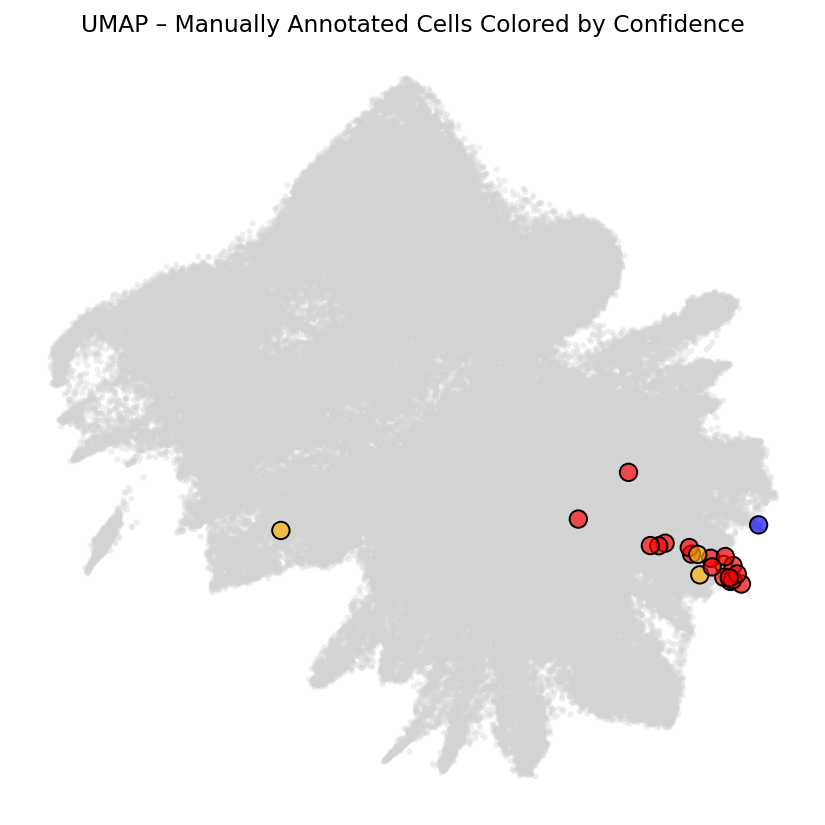

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract mask for manually annotated cells
manual_mask = adata.obs["confidence"].notna()

# Get indices of these cells
manual_indices = [adata.obs_names.get_loc(c) for c in adata.obs_names[manual_mask]]

# UMAP coordinates
umap = adata.obsm["X_umap"]

# Confidence → colors
conf_colors = {
    "High":   (1, 0, 0, 0.65),      # red
    "Middle": (1, 0.7, 0, 0.65),    # orange
    "Low":    (0, 0, 1, 0.65),      # blue
}

# Map confidence values to RGBA colors
manual_colors = [
    conf_colors.get(conf, (0, 0, 0, 1)) 
    for conf in adata.obs.loc[manual_mask, "confidence"]
]

# ---- PLOT ----
plt.figure(figsize=(6, 6), dpi=140)

# Background cells
plt.scatter(
    umap[:, 0], umap[:, 1],
    c="lightgray",
    s=5, alpha=0.25
)

# Overlay manually scored cells
plt.scatter(
    umap[manual_indices, 0],
    umap[manual_indices, 1],
    s=80,
    c=manual_colors,
    edgecolors="black",
    linewidths=1.0,
    label="Manual-annotated cells"
)

plt.title("UMAP – Manually Annotated Cells Colored by Confidence")
plt.xticks([]); plt.yticks([])
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()